# Fast committor transfer with a cached SelfTICA representation

This tutorial shows how to reuse a pretrained SelfTICA encoder for committor
learning **without evaluating the encoder at every training step**.

The workflow has two stages:

```text
1. Cache once

raw coordinates R
      ↓
frozen SelfTICA encoder
      ↓
latent representation h(R)
      ↓
cache h(R) and dh/dR


2. Train many epochs

cached h(R)
      ↓
linear TaskHead
      ↓
committor loss
```

During committor training, only the small `TaskHead` is optimized. The
pretrained SelfTICA encoder is not part of the training loop.

The cached Jacobian `dh/dR` is used to recover derivatives with respect to the
original coordinates through the chain rule.


## 1. Setup

We use the Müller–Brown potential as a small example. First, SelfTICA learns a
dynamical representation from a trajectory. We then freeze that representation,
cache it, and train only a linear committor head.


In [ ]:
import copy

import lightning
import matplotlib.pyplot as plt
import numpy as np
import torch

from mlcolvar.cvs import Committor, SelfTICA
from mlcolvar.cvs.committor.utils import (
    compute_committor_weights,
    initialize_committor_masses,
)
from mlcolvar.data import DictDataset, DictModule
from mlcolvar.io import create_dataset_from_files, load_dataframe
from mlcolvar.representation import (
    IdentityDescriptorDerivatives,
    MLColvarRepresentation,
    RepresentationInferenceModel,
    RepresentationModel,
    TaskHead,
    export_representation_torchscript,
    precompute_committor_cache,
)
from mlcolvar.utils.plot import (
    muller_brown_potential,
    plot_isolines_2D,
    plot_metrics,
)
from mlcolvar.utils.timelagged import create_timelagged_dataset
from mlcolvar.utils.trainer import MetricsCallback


torch.manual_seed(42)
torch.set_default_dtype(torch.float64)

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.


## 2. Train SelfTICA

SelfTICA is trained in the usual way.

The encoder maps the two input coordinates to a 5-dimensional latent space.
This latent space is the representation that we will transfer to the committor
task.


In [ ]:
trajectory = "data/muller-brown/unbiased/high-temp/COLVAR"

df = load_dataframe(
    [trajectory],
    start=0,
    stop=10000,
    stride=5,
)

X = df.filter(regex="p.x|p.y").values

dataset = create_timelagged_dataset(
    X,
    lag_time=1,
)

datamodule = DictModule(
    dataset,
    lengths=[0.8, 0.2],
)

selftica = SelfTICA(
    [2, 15, 15, 5],
    predictor_depth=3,
    n_cvs=1,
    options={
        "nn": {
            "activation": "shifted_softplus",
        }
    },
)

metrics = MetricsCallback()

trainer = lightning.Trainer(
    max_epochs=5,
    callbacks=[metrics],
    logger=False,
    enable_checkpointing=False,
)

trainer.fit(
    selftica,
    datamodule,
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type            | Params | Mode  | FLOPs | In sizes | Out sizes
-------------------------------------------------------------------------------------
0 | loss_fn   | ContrastiveLoss | 0      | train | 0     | ?        | ?        
1 | norm_in   | Normalization   | 0      | train | 0     | [1, 2]   | [1, 2]   
2 | nn        | FeedForward     | 365    | train | 660   | [1, 2]   | [1, 5]   
3 | predictor | FeedForward     | 60     | train | 0     | ?        | ?        
4 | tica      | TICA            | 0      | train | 0     | ?        | ?        
-------------------------------------------------------------------------------------
425       Trainable params
0         Non-trainable params
425       Total params
0.002     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode
670       Total Flops


Epoch 499: 100%|██████████| 1/1 [00:00<00:00, 59.44it/s]                   

`Trainer.fit` stopped: `max_epochs=500` reached.


Epoch 499: 100%|██████████| 1/1 [00:00<00:00, 56.98it/s]


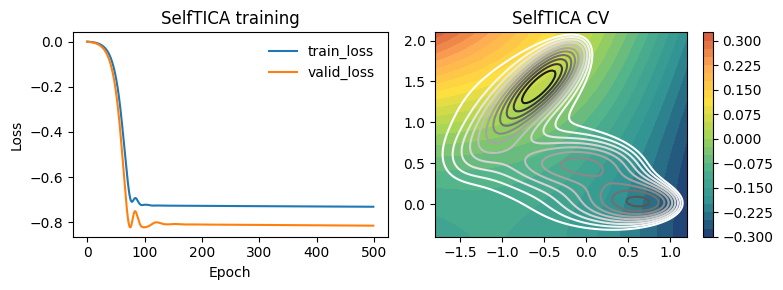

In [3]:
fig, axs = plt.subplots(
    1,
    2,
    figsize=(8, 3),
)

plot_metrics(
    metrics.metrics,
    keys=["train_loss", "valid_loss"],
    yscale="linear",
    ax=axs[0],
)
axs[0].set_title("SelfTICA training")

plot_isolines_2D(
    muller_brown_potential,
    levels=np.linspace(0, 24, 12),
    mode="contour",
    ax=axs[1],
)
plot_isolines_2D(
    selftica.eval(),
    component=0,
    levels=25,
    ax=axs[1],
)
axs[1].set_title("SelfTICA CV")

plt.tight_layout()
plt.show()


## 3. Expose and freeze the latent representation

`MLColvarRepresentation(..., mode="latent")` exposes the SelfTICA encoder
before the final TICA projection.

With `freeze=True`, the encoder parameters remain fixed.

At this point we have:

```text
R
↓
frozen SelfTICA encoder
↓
h(R)
```

where `h(R)` is a 5-dimensional dynamical representation.


In [4]:
representation = MLColvarRepresentation(
    selftica,
    mode="latent",
    freeze=True,
)

print("Input dimension :", representation.in_features)
print("Latent dimension:", representation.out_features)
print(
    "Trainable representation parameters:",
    sum(
        p.numel()
        for p in representation.parameters()
        if p.requires_grad
    ),
)


Input dimension : 2
Latent dimension: 5
Trainable representation parameters: 0


## 4. Prepare the committor dataset

We use two boundary-state trajectories and four biased trajectories containing
transition-region configurations.

The biased samples are reweighted before training.


In [5]:
T = 1.0
beta = 1.0 / T

root = (
    "https://raw.githubusercontent.com/"
    "EnricoTrizio/committor_2.0/"
    "refs/heads/main/muller/"
)

paths = [
    "unbiased_sims/A/COLVAR",
    "unbiased_sims/B/COLVAR",
    "biased_sims/iter_0/A/COLVAR",
    "biased_sims/iter_0/B/COLVAR",
    "biased_sims/iter_1/A/COLVAR",
    "biased_sims/iter_1/B/COLVAR",
]

load_args = (
    [{"start": 0, "stop": 2000, "stride": 1}] * 2
    + [{"start": 1000, "stop": 10000, "stride": 1}] * 4
)

committor_dataset, committor_df = create_dataset_from_files(
    file_names=[root + path for path in paths],
    create_labels=True,
    filter_args={"regex": "p.x|p.y"},
    return_dataframe=True,
    load_args=load_args,
    verbose=True,
)

bias = torch.tensor(
    committor_df[
        ["opes.bias", "bias"]
    ].fillna(0).sum(axis=1).values,
    dtype=torch.get_default_dtype(),
)

committor_dataset = compute_committor_weights(
    committor_dataset,
    bias,
    list(range(len(paths))),
    beta,
)

# The cache uses ref_idx to map each sample to its cached Jacobian.
committor_dataset = DictDataset(
    {
        "data": committor_dataset["data"],
        "labels": committor_dataset["labels"],
        "weights": committor_dataset["weights"],
        "ref_idx": torch.arange(
            len(committor_dataset),
            dtype=torch.long,
        ),
    }
)

print("Samples:", len(committor_dataset))
print("Raw input shape:", tuple(committor_dataset["data"].shape))


Class 0 dataframe shape:  (2000, 13)
Class 1 dataframe shape:  (2000, 13)
Class 2 dataframe shape:  (9000, 24)
Class 3 dataframe shape:  (9000, 24)
Class 4 dataframe shape:  (9000, 24)
Class 5 dataframe shape:  (9000, 24)

 - Loaded dataframe (40000, 27): ['time', 'p.x', 'p.y', 'p.z', 'ene', 'pot.bias', 'pot.ene_bias', 'lwall.bias', 'lwall.force2', 'uwall.bias', 'uwall.force2', 'walker', 'labels', 'mueller', 'potential.bias', 'potential.mueller_bias', 'z.node-0', 'z.bias-0', 'q', 'bias', '@8.bias', '@8.bias_bias', 'opes.bias', 'opes.rct', 'opes.zed', 'opes.neff', 'opes.nker']
 - Descriptors (40000, 2): ['p.x', 'p.y']
Samples: 40000
Raw input shape: (40000, 2)


/home/kzhu-iit.local/data/mlcolvar-featurizer/mlcolvar/io/colvar.py:292: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  dictionary["labels"] = torch.Tensor(df["labels"].values)


## 5. Cache the frozen representation

This is the key acceleration step.

Because the SelfTICA encoder is frozen, its output does not change during
committor training. We therefore compute only once:

```text
h(R)
dh/dR
```

and store both.

For the Müller–Brown example the input variables are already the two
coordinates of one particle, so the descriptor-to-coordinate derivative is
simply the identity.

`precompute_committor_cache` returns:

- a new dataset whose `data` field contains the cached latent representation;
- cached derivatives that apply the chain rule during the committor loss.

After this step, the SelfTICA encoder is no longer evaluated inside the
training loop.


In [ ]:
cached_dataset, cached_derivatives = precompute_committor_cache(
    representation=representation,
    dataset=committor_dataset,
    descriptor_derivatives=IdentityDescriptorDerivatives(),
    batch_size=1024,
    device="cpu",
    output_device="cpu",
    separate_boundary_dataset=True,
)

cached_datamodule = DictModule(
    cached_dataset,
    lengths=[1],
)

print(
    "Raw input shape:",
    tuple(committor_dataset["data"].shape),
)
print(
    "Cached latent shape:",
    tuple(cached_dataset["data"].shape),
)
print(
    "Cached Jacobian shape:",
    tuple(cached_derivatives.jacobian.shape),
)

Raw input shape   : (40000, 2)
Cached latent shape: (40000, 5)
Cached Jacobian shape: (36000, 1, 2, 5)


### What is cached?

For each configuration, the expensive frozen encoder is evaluated once:

```text
R ── SelfTICA encoder ──> h
```

For samples entering the variational loss, the representation Jacobian is also
cached:

```text
dh/dR
```

During training PyTorch only differentiates through the small head to obtain
`dq/dh`. The cached derivative then gives `dq/dR` through the chain rule:

```text
dq/dR = dq/dh × dh/dR
```

So the expensive SelfTICA network does not participate in every optimization
step.


## 6. Train only the task head

Now the committor receives **cached latent features**, not the original
coordinates.

Therefore the model passed to `Committor` is only a `TaskHead`:

```text
cached h(R)
    ↓
linear TaskHead
    ↓
z
    ↓
sigmoid
    ↓
q
```

Only the parameters of this head are optimized.


In [7]:
head = TaskHead(
    representation.out_features,
    n_out=1,
    hidden_layers=(),
)

atomic_masses = initialize_committor_masses(
    atom_types=[0],
    masses=[1],
)

committor = Committor(
    model=head,
    atomic_masses=atomic_masses,
    alpha=1e-1,
    delta_f=0,
    n_dim=2,
    norm_in=False,
    separate_boundary_dataset=True,
    descriptors_derivatives=cached_derivatives,
    options={
        "optimizer": {
            "lr": 1e-3,
            "weight_decay": 1e-5,
        },
        "lr_scheduler": {
            "scheduler": torch.optim.lr_scheduler.ExponentialLR,
            "gamma": 0.99999,
        },
    },
)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in committor.parameters()
        if p.requires_grad
    ),
)

for name, parameter in committor.named_parameters():
    if parameter.requires_grad:
        print("TRAIN:", name, tuple(parameter.shape))


Trainable parameters: 6
TRAIN: nn.nn.0.weight (1, 5)
TRAIN: nn.nn.0.bias (1,)


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'descriptors_derivatives' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['descriptors_derivatives'])`.


In [ ]:
COMMITTOR_EPOCHS = 5

committor_metrics = MetricsCallback()

committor_trainer = lightning.Trainer(
    max_epochs=COMMITTOR_EPOCHS,
    callbacks=[committor_metrics],
    logger=False,
    enable_checkpointing=False,
    limit_val_batches=0,
    num_sanity_val_steps=0,
)

committor_trainer.fit(
    committor,
    cached_datamodule,
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type           | Params | Mode  | FLOPs | In sizes | Out sizes
----------------------------------------------------------------------------------
0 | loss_fn | CommittorLoss  | 0      | train | 0     | ?        | ?        
1 | nn      | TaskHead       | 6      | train | 10    | [1, 5]   | [1, 1]   
2 | sigmoid | Custom_Sigmoid | 0      | train | 0     | [1, 1]   | [1, 1]   
----------------------------------------------------------------------------------
6         Trainable params
0         Non-trainable params
6         Total params
0.000     Total estimated model params size (MB)
6         Modules in train mode
0         M

Epoch 49999: 100%|██████████| 1/1 [00:00<00:00, 27.53it/s]

`Trainer.fit` stopped: `max_epochs=50000` reached.


Epoch 49999: 100%|██████████| 1/1 [00:00<00:00, 26.89it/s]


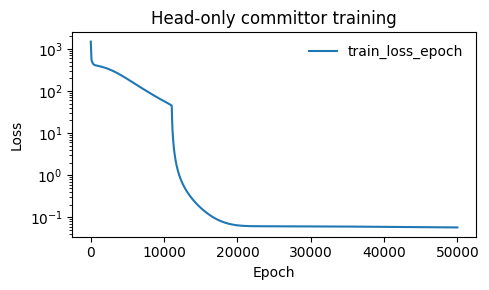

In [9]:
fig, ax = plt.subplots(
    figsize=(5, 3)
)

plot_metrics(
    committor_metrics.metrics,
    keys=["train_loss_epoch"],
    ax=ax,
    yscale="log",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Head-only committor training")

plt.tight_layout()
plt.show()


## 7. Reattach the trained head for inference

Caching is only a training optimization.

For inference we want a model that again accepts the original coordinates.
We therefore attach the trained head back to the frozen SelfTICA
representation:

```text
raw coordinates R
      ↓
frozen SelfTICA representation
      ↓
trained TaskHead
      ↓
z
      ↓
Committor sigmoid
      ↓
q
```

This restores the complete raw-input model without changing the parameters
learned from the cached training.


In [ ]:
import copy

# Use the head that was actually optimized inside Committor.
trained_head = copy.deepcopy(
    committor.nn
).eval()

# Use exactly the same sigmoid as Committor.
trained_sigmoid = copy.deepcopy(
    committor.sigmoid
).eval()


# Complete raw-input model:
# R -> frozen representation -> trained head
raw_model = RepresentationModel(
    representation,
    head=trained_head,
).eval()


# Add the committor postprocessing:
# R -> representation -> head -> sigmoid -> q(R)
raw_committor = RepresentationInferenceModel(
    model=raw_model,
    postprocessing=trained_sigmoid,
).eval()


x_committor = committor_dataset["data"]
h_cached = cached_dataset["data"]


with torch.no_grad():
    # 1. Cached representation must match direct evaluation.
    h_raw = representation(
        x_committor
    )

    torch.testing.assert_close(
        h_raw,
        h_cached,
        rtol=1e-6,
        atol=1e-7,
    )

    # 2. Head output must match.
    z_cached = committor.nn(
        h_cached
    )

    z_raw = raw_model(
        x_committor
    )

    torch.testing.assert_close(
        z_raw,
        z_cached,
        rtol=1e-6,
        atol=1e-7,
    )

    # 3. Final committor must match.
    q_cached = committor.sigmoid(
        z_cached
    )

    q_raw = raw_committor(
        x_committor
    )

    torch.testing.assert_close(
        q_raw,
        q_cached,
        rtol=1e-6,
        atol=1e-7,
    )


print("Cached and raw paths agree.")
print(
    "q range:",
    float(q_raw.min()),
    float(q_raw.max()),
)

Cached and raw paths agree.
q range: 1.801547088016599e-08 1.0


## 8. Visualize the committor

The final model accepts the original Müller–Brown coordinates, so it can be
used like any other mlcolvar model for plotting or deployment.


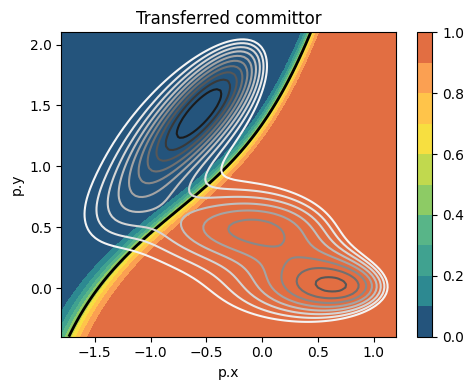

In [11]:
fig, ax = plt.subplots(
    figsize=(5, 4)
)

plot_isolines_2D(
    raw_committor,
    levels=np.linspace(0, 1, 11),
    colorbar=True,
    ax=ax,
)

plot_isolines_2D(
    raw_committor,
    levels=[0.5],
    mode="contour",
    linewidths=2,
    ax=ax,
)

plot_isolines_2D(
    muller_brown_potential,
    levels=np.linspace(0, 24, 12),
    mode="contour",
    max_value=24,
    colorbar=False,
    ax=ax,
)

ax.set_xlabel("p.x")
ax.set_ylabel("p.y")
ax.set_title("Transferred committor")

plt.tight_layout()
plt.show()


## 9. Export the complete raw-input model

Training used cached latent features, but deployment should use the complete
model.

`export_representation_torchscript` combines the frozen representation, the
trained head, and the sigmoid into one model that accepts the original
coordinates.


In [12]:
example_input = x_committor[:1].detach().cpu()

export_representation_torchscript(
    model=raw_model,
    postprocessing=trained_sigmoid,
    path="selftica_committor.pt",
    example_input=example_input,
    dtype=torch.get_default_dtype(),
)

print("Saved selftica_committor.pt")


Saved selftica_committor.pt


/home/kzhu-iit.local/data/mlcolvar-featurizer/mlcolvar/representation/model.py:93: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if x.shape[-1] != self.in_features:
/home/kzhu-iit.local/data/mlcolvar-featurizer/mlcolvar/representation/adapters/mlcolvar.py:180: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if x.shape[-1] != self.in_features:
/home/kzhu-iit.local/data/mlcolvar-featurizer/mlcolvar/representation/adapters/mlcolvar.py:204: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data 

## Summary

The important distinction is between **training** and **inference**.

During training:

```text
cached h(R) + cached dh/dR
              ↓
         TaskHead only
              ↓
        committor loss
```

The frozen SelfTICA encoder is evaluated only once when the cache is built.

During inference:

```text
R
↓
frozen SelfTICA encoder
↓
trained TaskHead
↓
q(R)
```

This keeps the full raw-input model for deployment while making downstream
committor optimization much cheaper.
